# Mock Member Health Analysis - Model Interpretation


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


## 2. Load Processed Dataset

In [2]:
df = pd.read_csv("../data/processed/member_analysis_ready.csv")
df.head()

,member_id,age,gender,region,plan_type,sdoh_risk_score,chronic_condition_count,engagement_score,pcp_attributed_24mo,prior_awv_count,...,engagement_group,age_group,high_cost_member,chronic_burden_group,sdoh_risk_group,prior_awv_group,total_acute_visits,acute_utilization_group,pcp_status,has_acute_utilization
0,M00001,69,Male,Suburban,Medicare Advantage,40.7,2,68.9,1,1,...,Q4_High,65-79,1,Moderate,Q1_Low,1,2,Low,Attributed,1
1,M00002,32,Female,Urban,DSNP,80.0,3,30.4,0,0,...,Q1_Low,18-34,0,Moderate,Q4_High,0,2,Low,Not Attributed,1
2,M00003,89,Female,Suburban,Medicare Advantage,49.6,3,86.3,1,3,...,Q4_High,80+,0,Moderate,Q2,3,0,NaN,Attributed,0
3,M00004,78,Male,Suburban,Medicare Advantage,45.7,4,63.1,1,1,...,Q4_High,65-79,1,High,Q1_Low,1,3,Moderate,Attributed,1
4,M00005,38,Male,Suburban,Medicare Advantage,32.4,0,55.6,0,0,...,Q4_High,35-49,0,Low,Q1_Low,0,0,NaN,Not Attributed,0


In [3]:
target = "awv_completed"

# Match the baseline feature set from 03_modeling_baseline.ipynb.
# These fields are removed because they are identifiers, outcomes, cost-related fields,
# or grouped/duplicated versions of predictors already represented in raw numeric columns.
drop_cols = [
    "member_id",
    target,
    "monthly_cost",
    "high_cost_member",
    "engagement_group",
    "sdoh_risk_group",
    "age_group",
    "chronic_burden_group",
    "pcp_status",
    "total_acute_visits",
    "acute_utilization_group",
    "has_acute_utilization",
    "prior_awv_count",
    "prior_awv_group"
]

X = df.drop(columns=drop_cols)
y = df[target]


## 3. Rebuild Baseline Logistic Regression

In [4]:
# Use a train/validation/test split so threshold selection does not use the final test set.
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])
print("Test size:", X_test.shape[0])


Train size: 1800
Validation size: 600
Test size: 600


In [5]:
categorical_cols = X.select_dtypes(
    include=["object", "string", "category", "bool"]  # Select categorical/text-like columns
).columns.tolist()  # Store categorical column names

numeric_cols = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]  # Select numeric columns
).columns.tolist()  # Store numeric column names

In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            categorical_cols
        ),  # One-hot encode categorical predictors

        (
            "num",
            StandardScaler(),
            numeric_cols
        )  # Standardize numeric predictors for logistic regression coefficient interpretation
    ]
)

In [7]:
log_model = Pipeline(steps = [
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=3000)) 
])
# Fit the full pipeline on the training data.
# The pipeline first preprocesses categorical and numeric features,
# then fits Logistic Regression.
log_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## 4. Review Class Balance

In [8]:
df["awv_completed"].value_counts(normalize = True) # Check the distribution of the target variable to understand class imbalance, which can impact model performance and may require techniques such as resampling or class weighting if the classes are highly imbalanced.


awv_completed
1    0.519333
0    0.480667
Name: proportion, dtype: float64

## 5. Evaluate Predictions More Deeply

The AWV target is fairly balanced, so class imbalance is not a major issue in this synthetic dataset. However, accuracy alone is still insufficient because it does not show the balance between false positives and false negatives.

In [9]:
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

# Validation probabilities are used only for threshold selection.
y_val_prob = log_model.predict_proba(X_val)[:, 1]


In [10]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("Precision", precision_score(y_test, y_pred, zero_division = 0))

print("Recall:", recall_score(y_test, y_pred, zero_division=0))  # Measure how many actual positives were captured

print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))  # Balance precision and recall

print("ROC AUC:", roc_auc_score(y_test, y_prob))  # Measure ranking ability across probability thresholds

print("\nConfusion Matrix:")  # Print raw classification error breakdown
print(confusion_matrix(y_test, y_pred))  # Show true negatives, false positives, false negatives, and true positives

print("\nClassification Report:")  # Print precision, recall, and F1 by class
print(classification_report(y_test, y_pred, zero_division=0))  # Show full classification report

Accuracy: 0.6933333333333334
Precision 0.6930091185410334
Recall: 0.7331189710610932
F1 Score: 0.7125
ROC AUC: 0.7446900833342605

Confusion Matrix:
[[188 101]
 [ 83 228]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.65      0.67       289
           1       0.69      0.73      0.71       311

    accuracy                           0.69       600
   macro avg       0.69      0.69      0.69       600
weighted avg       0.69      0.69      0.69       600



## 6. Interpret Logistic Regression Coefficients

### Step A: get transformed feature names

In [11]:
all_feature_names = log_model.named_steps["preprocessor"].get_feature_names_out()
all_feature_names = [name.replace("cat__", "").replace("num__", "") for name in all_feature_names]


### Step B: get coefficients

In [12]:
coefficients = log_model.named_steps["model"].coef_[0]  # Extract logistic regression coefficients for the positive class

coef_df = pd.DataFrame({
    "feature": all_feature_names,  # Store transformed feature names
    "coefficient": coefficients  # Store model coefficients on the log-odds scale
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()  # Create absolute coefficient size for sorting
coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])  # Convert log-odds coefficients into odds ratios

coef_df = coef_df.sort_values(
    "abs_coefficient",
    ascending=False
)  # Sort features by strongest coefficient magnitude

coef_df.head(15)  # Display top coefficients


,feature,coefficient,abs_coefficient,odds_ratio
8,engagement_score,0.509445,0.509445,1.664367
10,prior_awv_rate,0.392995,0.392995,1.481411
0,gender_Male,0.343021,0.343021,1.409199
9,pcp_attributed_24mo,0.293525,0.293525,1.341147
5,age,0.195949,0.195949,1.216465
6,sdoh_risk_score,-0.181943,0.181943,0.833648
11,ed_visits,-0.154742,0.154742,0.856636
4,plan_type_Medicare Advantage,-0.105116,0.105116,0.900220
1,region_Suburban,-0.059303,0.059303,0.942421
7,chronic_condition_count,-0.049366,0.049366,0.951832


For example, `engagement_score` has a positive coefficient and odds ratio above 1. Because numeric variables were standardized, this means a one-standard-deviation increase in engagement score is associated with higher predicted odds of AWV completion, holding other included variables constant.

## 7. Test Different Classification Thresholds

In [13]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
threshold_results = []

for threshold in thresholds:
    y_val_pred_thresh = (y_val_prob >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "validation_accuracy": accuracy_score(y_val, y_val_pred_thresh),
        "validation_precision": precision_score(y_val, y_val_pred_thresh, zero_division=0),
        "validation_recall": recall_score(y_val, y_val_pred_thresh, zero_division=0),
        "validation_f1_score": f1_score(y_val, y_val_pred_thresh, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df


,threshold,validation_accuracy,validation_precision,validation_recall,validation_f1_score
0,0.3,0.641667,0.600414,0.929487,0.729560
1,0.4,0.681667,0.649383,0.842949,0.733612
2,0.5,0.683333,0.683735,0.727564,0.704969
3,0.6,0.665000,0.724696,0.573718,0.640429
4,0.7,0.623333,0.779221,0.384615,0.515021


## 8. Compare Threshold Tradeoffs

The best F1 threshold is selected on the validation set. This keeps the final test set untouched until the final evaluation step, which better reflects how model tuning should work in a production-style workflow.


In [14]:
best_f1_threshold = threshold_df.sort_values(
    "validation_f1_score",
    ascending=False
).iloc[0]

best_threshold = best_f1_threshold["threshold"]
best_f1_threshold


threshold               0.400000
validation_accuracy     0.681667
validation_precision    0.649383
validation_recall       0.842949
validation_f1_score     0.733612
Name: 1, dtype: float64

## 8B. Evaluate Selected Threshold on Final Test Set


In [15]:
y_test_pred_selected = (y_prob >= best_threshold).astype(int)

print("Selected threshold:", best_threshold)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_selected))
print("Test Precision:", precision_score(y_test, y_test_pred_selected, zero_division=0))
print("Test Recall:", recall_score(y_test, y_test_pred_selected, zero_division=0))
print("Test F1 Score:", f1_score(y_test, y_test_pred_selected, zero_division=0))

print()
print("Confusion Matrix at Selected Threshold:")
print(confusion_matrix(y_test, y_test_pred_selected))


Selected threshold: 0.4
Test Accuracy: 0.6716666666666666
Test Precision: 0.6397058823529411
Test Recall: 0.8392282958199357
Test F1 Score: 0.7260083449235049

Confusion Matrix at Selected Threshold:
[[142 147]
 [ 50 261]]


At the selected 0.40 threshold, the model correctly identified 261 AWV-completed members and 142 non-completed members. Compared with the default 0.50 threshold, the 0.40 threshold increases recall by reducing false negatives, but it also increases false positives. This tradeoff may be acceptable in an outreach setting if the priority is to capture more members likely to complete AWVs or reduce missed opportunities.

Because the positive class is `awv_completed = 1`, recall measures how many completed AWVs the model captures. If the operational goal is outreach to members at risk of not completing AWVs, a future version should either model `awv_not_completed` as the positive class or interpret probabilities in the opposite direction.

## 9. Plot Threshold Tradeoffs

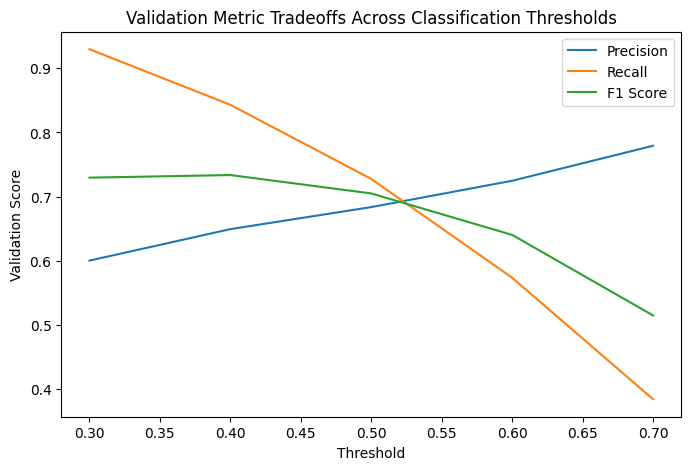

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["validation_precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["validation_recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["validation_f1_score"], label="F1 Score")
plt.xlabel("Threshold")
plt.ylabel("Validation Score")
plt.title("Validation Metric Tradeoffs Across Classification Thresholds")
plt.legend()
plt.show()


## Findings

1. The target variable is fairly balanced, with 51.9% AWV-completed members and 48.1% non-completed members. Accuracy is still not enough by itself because precision, recall, F1, and ROC AUC describe different kinds of model behavior.

2. This reviewed copy uses the same baseline feature set as the prior modeling notebook. Grouped or duplicate engineered fields were excluded so the coefficient interpretation is cleaner.

3. Logistic regression coefficients show conditional associations with predicted AWV completion. Positive coefficients increase the predicted log-odds of AWV completion, while negative coefficients decrease the predicted log-odds, holding other included variables constant.

4. Because numeric variables were standardized, numeric coefficients represent the change in log-odds associated with a one-standard-deviation increase in the predictor. Dummy-variable coefficients represent differences relative to the omitted reference category.

5. Odds ratios make coefficient interpretation more intuitive. Odds ratios above 1 indicate higher predicted odds of AWV completion, while odds ratios below 1 indicate lower predicted odds.

6. Threshold tradeoffs were evaluated on a validation set, then the selected threshold was applied once to the final test set. This avoids tuning the classification threshold directly on the final test data.

7. These relationships reflect learned patterns in synthetic data and should not be interpreted as causal effects. In a real healthcare workflow, every predictor should also be checked to confirm it is available before the AWV completion outcome window.
